## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jacob Khaykin

**Date:** 09/30/2026


## Q1

**1.** The difference is that regression predicts a numeric outcome, this allows a prediction to be "close" or "far." Whereas, classification predicts a category, so a prediction is either right or wrong, class probabilities are definetely important for some measure.

**2** A confussion table is a cross-tabulation of actual class labels against predicted labels. The diagonal of the table counts the correct predictions (when actual equaled predicted). Off-diagonal cells show which classes get confused with which. This is especially important as it can tell us more than overall accuracy as a model can be accurate overall but consistently mistake one class for another. Having this knowledge can allow us to improve the model in specific ways depending on if there is a pattern in the off-diagonals.

**3.** The sum of squared errors measures the total or sum of all of the squared distance between the model's predictions and the actual values. Squaring the errors is especially important as it removes the sign and it additionally penalizes big misses more than small ones. Lower SSE on the data means the model fits and predicts better.

**4.** Overfitting is where the model is too flexible and learns noise in the training data. This causes it to do well in training but poorly on new data. Underfitting is quite the opposite, it occurs when the model is too rigid to capture the real pattern and, it therefore does poorly everywhere.

**5.** Evaluating on the same data used to fit always favors the most flexible model (which is always going to be k = 1). However, held-out test data mimics new observations, so accuracy or SSE there estimates real predictive performance. Therefore, picking the k that does best on the test set balances over- and underfitting.

**6.** A single label is very simple and easy to act on, but the main problem is that it hides uncertainty. For example, a 33% call would look as confident as a 100% one. A probability distribution, however, shows how confident the model is and lets the user apply their own thresholds or costs. The main downside is that it is harder to communicate, it also still requires a decision rule in the end, and through k-NN the probabilities are coarse (1/k) and not necessarily well calibrated.

## Q2

**1.** The data has 338 mines and there are no missing values in any of the columns. The target, mine_type, is close to balanced, with between 65 and 71 mines of each type, so no single type dominates the data. All three features are already between 0 and 1. Soil only takes six values (0, 0.2, 0.4, 0.6, 0.8 and 1), so it acts more like a category than a continuous measurement. The violin plots show that voltage is the feature that differs the most across mine types, while height and soil look fairly similar for every type. This means voltage will most likely do most of the work in separating the mines.

**2.** I split the data as per the instrunctions 50/50 using train_test_split. Given the data has 338 mines it, accordingly, gave 169 mines in the training set and 169 in the validation set. I set random_state so the split is the same every time the code runs. I then checked the counts of each mine type in both halves, and every type shows up in both sets (between 28 and 38 of each), so no class was left out of training. After splitting, I scaled the features with MinMaxScaler, and then fitting it on the training data only and then applying the same scaling to the validation data. This is important because kNN grouping uses Euclidean distance. Therefore the features need to be on the same scale.

**3.** I built a kNN classifier and fit it for every k from 1 to 50 on the training set, then computed the accuracy of each model on the validation set. I chose the k with the highest validation accuracy, which was k = 2 for this split. Because k = 1 would be the more accurate per training accuracy, I did not pick k using training accuracy because it will always favor very small k, since at k = 1 every training mine is its own nearest neighbor. Then as k increases, the validation accuracy falls because each prediction averages over more mines, which causes the model to underfit. A different split could give a different best k.

**4.** With k = 2, the model classifies about 49% of the validation mines correctly. Because there are 5 different mine types, a 0.49 accuracy is about 2.5 times better than the 20% you would get by guessing randomly, but it is still wrong about half the time. The confusion table shows more patterns, specifically that performance is very uneven across types. Although type 2 is predicted correctly 83% of the time and type 1 74% of the time, types 3, 4 and 5 are much worse, at 45%, 26% and 7% correct. I think that the type 1 was predicted so accurately because through the violin plot, a smaller voltage is a big correlate towards type 1. These types are often confused with each other, and many of them are predicted as type 1. Of the 59 mines predicted as type 1, 31 were actually another type, so a type 1 prediction is not very trustworthy (also makes sense as types 3-5 also can have smaller values, so I'm assuming that the model predicts type 1 for a lot of actual types 3-5).

**5.** I would advise someone to use this model as a tool to support a decision, not to make the final decision (especially becuase mines are very serious). Since it misses most mines of types 3, 4 and 5 and often calls them type 1, trusting the label alone could mean using the wrong procedure on a live mine. Instead of only reporting the predicted label, the model should also show how the nearest neighbors voted, because if the neighbors are split between types the prediction is uncertain and more checking is needed. When the model is unsure between types that are handled differently, the safer procedure should be used. The model is most useful for planning as you can have a better sense of what type of mine to expect, such as deciding what equipment or specialist to send, and the mine type should be confirmed with inspection or other sensors before acting. Finally, collecting more data and better features would help, since height and soil add very little and the model struggles to separate types 3 to 5 (height and soil variations seem extremly static).

**The code used for Q2 is in the cell below.**

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
       voltage   height     soil  mine_type
count  338.000  338.000  338.000    338.000
mean     0.431    0.509    0.504      2.953
std      0.196    0.306    0.344      1.420
min      0.198    0.000    0.000      1.000
25%      0.310    0.273    0.200      2.000
50%      0.360    0.545    0.600      3.000
75%      0.483    0.727    0.800      4.000
max      1.000    1.000    1.000      5.000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


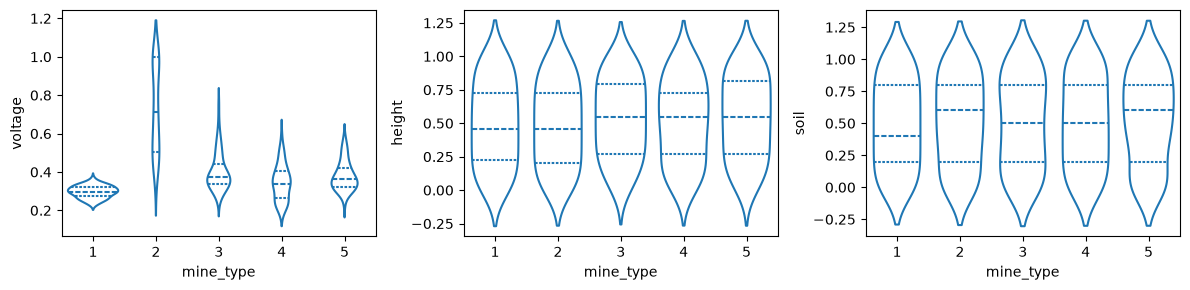

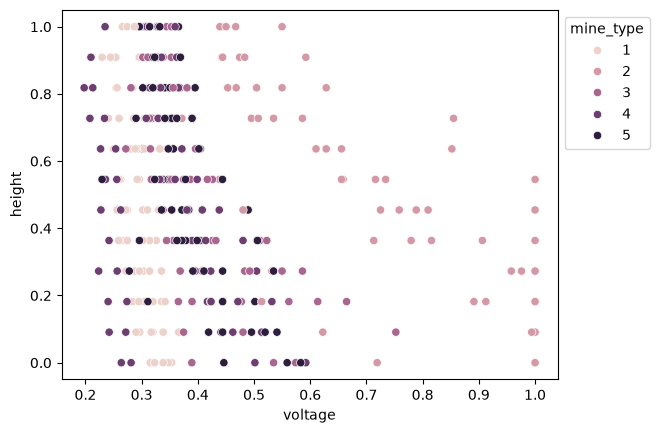

169 169
           count  count
mine_type              
5             37     28
2             35     35
1             33     38
3             33     33
4             31     35
best k: 2  validation accuracy: 0.491


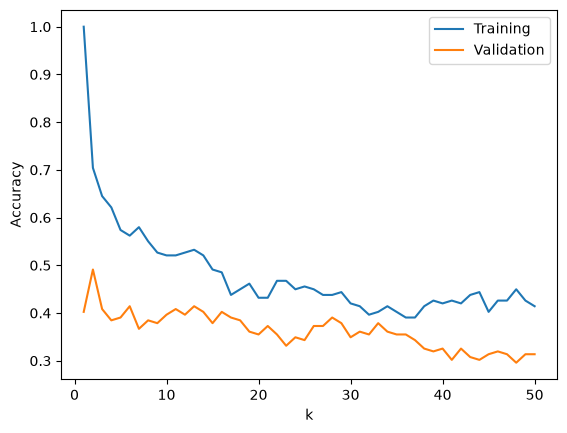

col_0       1   2   3  4  5
mine_type                  
1          28   0   9  1  0
2           0  29   3  1  2
3           8   0  15  5  5
4          13   2  11  9  0
5          10   0  12  4  2
Accuracy: 0.491
mine_type
5    0.5
3    0.5
Name: count, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("./data/land_mines.csv")
print(df.shape)
print(df.isnull().sum())
print(df.describe().round(3))
print(df["mine_type"].value_counts())
print(df["soil"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.violinplot(data=df, x="mine_type", y="voltage", inner="quart", fill=False, ax=axes[0])
sns.violinplot(data=df, x="mine_type", y="height", inner="quart", fill=False, ax=axes[1])
sns.violinplot(data=df, x="mine_type", y="soil", inner="quart", fill=False, ax=axes[2])
plt.tight_layout()
plt.show()

ax = sns.scatterplot(data=df, x="voltage", y="height", hue="mine_type")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

X_raw = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, test_size=0.50, random_state=100
)
print(len(X_train_raw), len(X_valid_raw))
print(pd.concat([y_train.value_counts(), y_valid.value_counts()], axis=1))

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

ks = np.arange(1, 51)
valid_acc = []
train_acc = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    valid_acc.append(np.mean(model.predict(X_valid) == y_valid))
    train_acc.append(np.mean(model.predict(X_train) == y_train))
k_star = int(ks[np.argmax(valid_acc)])
print("best k:", k_star, " validation accuracy:", round(max(valid_acc), 3))

plt.plot(ks, train_acc, label="Training")
plt.plot(ks, valid_acc, label="Validation")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)
table = pd.crosstab(y_valid, y_hat)
print(table)
print("Accuracy:", round(np.mean(y_hat == y_valid), 3))

distances = np.sqrt(np.sum((X_train - X_valid[0]) ** 2, axis=1))
neighbors = np.argsort(distances)[:k_star].tolist()
g_star = y_train.iloc[neighbors]
print(g_star.value_counts() / k_star)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided — paste the SHA of the Phase 1 commit]
- **AI tool and model used:** Claude Code (Claude Opus 5.5)

### *Prompts used

1. Hey Claude, I have been working on this assignmnet for my ML class, I have finished phase 1, I am looking for important proposed changes you may have based on my code and/or my solution process, the file is attached to this prompt.

### *AI-proposed changes


1. Fix the k = 2 tie problem. With an even k, a 1–1 neighbor vote is a tie, and scikit-learn breaks ties by picking the smallest class label. That means ties always go to type 1 and type 5 can never win a tie, which partly explains why so many mines get predicted as type 1 and type 5 is almost never predicted. Report this and show the neighbor vote.
2. Use stratify=y in train_test_split so each mine type is split evenly between training and validation.
3. Choose k with 5-fold cross-validation on the training set (and check the result over many random splits) instead of one validation split, since a single split with 169 mines is noisy and k was picked on the same data used to report accuracy.
4. Report that the 0.491 accuracy is optimistic: averaged over 50 stratified splits, k = 2 gets about 0.40 accuracy (sd ≈ 0.03), and the chosen split was a lucky one.
5. Add per-class precision and recall (classification_report) to back up the Q2.4 discussion with exact numbers.
6. MinMaxScaler is harmless but does nothing here because every feature is already between 0 and 1; say so instead of implying it was needed.
7. Q1.5: add that picking k on the test set makes the test accuracy optimistic, so ideally k is chosen with cross-validation and a separate test set is used only once at the end.
8. Fix typos (definetely, confussion, instrunctions, becuase, extremly) and the Q1.1 sentence about class probabilities.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I did not know that, so I checked the scikit-learn docs and the neighbor vote printed at the end of my Phase 1 code (0.5 type 5, 0.5 type 3), which was a tie. This is a real problem with even k and explains a lot of the type 1 predictions I noticed in Q2.4. |
| 2 | Accept | Easy fix and it makes the class counts in both halves almost equal. I re-ran the counts to check. |
| 3 | Accept | I ran 5-fold CV and it still picked k = 2, so my choice of k holds up, but now it's picked in a fairer way. |
| 4 | Accept | I re-ran over 50 seeds and got about 0.40, and k = 2 was the best k in 34 of the 50 splits. So my Phase 1 number of 0.49 was too high. |
| 5 | Accept | Gives the exact precision/recall numbers instead of me working them out from the table by hand. |
| 6 | Modify | I kept the scaler because it would matter if new data came in on a different scale, but I changed my explanation. |
| 7 | Accept | This is correct, choosing k on the test set leaks information into the test accuracy. |
| 8 | Accept | Just spelling fixes. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

## Q1

**1.** The difference is that regression predicts a numeric outcome, which allows a prediction to be "close" or "far." Whereas, classification predicts a category, so a prediction is either right or wrong. Because of this, classification is judged with things like accuracy and class probabilities rather than how far off the prediction was.

**2.** A confusion table is a cross-tabulation of actual class labels against predicted labels. The diagonal of the table counts the correct predictions (when actual equaled predicted). Off-diagonal cells show which classes get confused with which. This is especially important as it can tell us more than overall accuracy, as a model can be accurate overall but consistently mistake one class for another. Having this knowledge can allow us to improve the model in specific ways depending on if there is a pattern in the off-diagonals.

**3.** The sum of squared errors measures the total or sum of all of the squared distances between the model's predictions and the actual values. Squaring the errors is especially important as it removes the sign and it additionally penalizes big misses more than small ones. Lower SSE on the data means the model fits and predicts better.

**4.** Overfitting is where the model is too flexible and learns noise in the training data. This causes it to do well in training but poorly on new data. Underfitting is quite the opposite, it occurs when the model is too rigid to capture the real pattern and it therefore does poorly everywhere.

**5.** Evaluating on the same data used to fit always favors the most flexible model (which is always going to be k = 1). However, held-out test data mimics new observations, so accuracy or SSE there estimates real predictive performance. Therefore, picking the k that does best on the test set balances over- and underfitting. One catch is that once k is chosen using the test set, the test accuracy is a bit optimistic, since we picked the k that happened to do best on that specific data. A better approach is to choose k with cross-validation on the training data and only use the test set once at the end.

**6.** A single label is very simple and easy to act on, but the main problem is that it hides uncertainty. For example, a 33% call would look as confident as a 100% one. A probability distribution, however, shows how confident the model is and lets the user apply their own thresholds or costs. The main downside is that it is harder to communicate, it also still requires a decision rule in the end, and through k-NN the probabilities are coarse (1/k) and not necessarily well calibrated.

## Q2

**1.** The data has 338 mines and there are no missing values in any of the columns. The target, mine_type, is close to balanced, with between 65 and 71 mines of each type, so no single type dominates the data. All three features are already between 0 and 1. Soil only takes six values (0, 0.2, 0.4, 0.6, 0.8 and 1), so it acts more like a category than a continuous measurement. The violin plots show that voltage is the feature that differs the most across mine types, while height and soil look fairly similar for every type. This means voltage will most likely do most of the work in separating the mines.

**2.** I split the data 50/50 using train_test_split, which gave 169 mines in the training set and 169 in the validation set. This time I used `stratify=y`, so each mine type is split about evenly between the two halves (every type has 32 to 36 mines in each set), so no class is left out or underrepresented in training. I set random_state so the split is the same every time the code runs. After splitting, I scaled the features with MinMaxScaler, fitting it on the training data only and then applying the same scaling to the validation data. Since the features are already between 0 and 1 this barely changes anything here, but kNN uses Euclidean distance, so keeping the features on the same scale matters if new data comes in on a different range.

**3.** I built a kNN classifier and, instead of picking k from one validation split, I used 5-fold cross-validation on the training set for every k from 1 to 30. The best k was k = 2 (CV accuracy about 0.40). To check this wasn't a fluke, I also repeated a stratified 50/50 split 50 times, and k = 2 had the highest average validation accuracy and was the best k in 34 of the 50 splits. I did not pick k using training accuracy because it will always favor very small k, since at k = 1 every training mine is its own nearest neighbor. As k increases, accuracy falls because each prediction averages over more mines, which causes the model to underfit. One problem with k = 2 is that ties are common (one neighbor votes each way), and scikit-learn breaks ties by choosing the smallest class label. So every tie goes to the lower-numbered type, which pushes predictions toward type 1 and means type 5 basically never wins a tie. The neighbor vote at the end of the code shows this kind of split vote.

**4.** With k = 2 on the stratified split, the model classifies about 40% of the validation mines correctly. This is lower than the 49% I got in Phase 1, but averaging over 50 splits gives about 0.40 (sd about 0.03), so my Phase 1 split was just a lucky one and 0.40 is the more honest number. Because there are 5 different mine types, 40% is about 2 times better than the 20% you would get by guessing randomly, but it is still wrong more often than right. The confusion table and classification report show that performance is very uneven across types. Type 2 is the most reliable (recall 0.77, precision 0.79) and type 1 is found often (recall 0.67), but types 3, 4 and 5 are much worse, with recalls of 0.30, 0.18 and 0.00. Type 1 has a low precision of 0.39, because 37 of the 61 mines predicted as type 1 were actually types 3 to 5. Part of this is because a small voltage correlates with type 1 (per the violin plot) and types 3 to 5 can also have small voltages, and part of it is the tie-breaking problem, since every tie gets pushed toward the lowest type number.

**5.** I would advise someone to use this model as a tool to support a decision, not to make the final decision (especially because mines are very serious). Since it misses most mines of types 3, 4 and 5 and often calls them type 1, trusting the label alone could mean using the wrong procedure on a live mine. Instead of only reporting the predicted label, the model should also show how the nearest neighbors voted, because if the neighbors are split between types (which happens a lot with k = 2) the prediction is uncertain and more checking is needed. When the model is unsure between types that are handled differently, the safer procedure should be used. A prediction of type 2 is fairly trustworthy, but a prediction of type 1 should be treated as "could be type 1, 3, 4 or 5." The model is most useful for planning as you can have a better sense of what type of mine to expect, such as deciding what equipment or specialist to send, and the mine type should be confirmed with inspection or other sensors before acting. Finally, collecting more data and better features would help, since height and soil add very little and the model struggles to separate types 3 to 5 (height and soil variations seem extremely static).

**The code used for Q2 is in the cell below.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

df = pd.read_csv("./data/land_mines.csv")
print(df.shape)
print(df.isnull().sum())
print(df.describe().round(3))
print(df["mine_type"].value_counts())
print(df["soil"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.violinplot(data=df, x="mine_type", y="voltage", inner="quart", fill=False, ax=axes[0])
sns.violinplot(data=df, x="mine_type", y="height", inner="quart", fill=False, ax=axes[1])
sns.violinplot(data=df, x="mine_type", y="soil", inner="quart", fill=False, ax=axes[2])
plt.tight_layout()
plt.show()

X_raw = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, test_size=0.50, random_state=100, stratify=y
)
print(len(X_train_raw), len(X_valid_raw))
print(pd.concat([y_train.value_counts(), y_valid.value_counts()], axis=1))

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

# choose k with 5-fold cross-validation on the training set
ks = np.arange(1, 31)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
cv_acc = [cross_val_score(KNeighborsClassifier(n_neighbors=int(k)), X_train, y_train, cv=cv).mean() for k in ks]
k_star = int(ks[np.argmax(cv_acc)])
print("best k:", k_star, " CV accuracy:", round(max(cv_acc), 3))

plt.plot(ks, cv_acc)
plt.xlabel("k")
plt.ylabel("5-fold CV accuracy")
plt.show()

# check over 50 different stratified splits
acc = np.zeros((50, len(ks)))
for s in range(50):
    a, b, c, d = train_test_split(X_raw, y, test_size=0.50, random_state=s, stratify=y)
    for j, k in enumerate(ks):
        acc[s, j] = np.mean(KNeighborsClassifier(n_neighbors=int(k)).fit(a, c).predict(b) == d)
best = np.argmax(acc.mean(axis=0))
print("best k on average:", int(ks[best]), " mean accuracy:", round(acc.mean(axis=0)[best], 3),
      " sd:", round(acc[:, best].std(), 3))
print(pd.Series(ks[acc.argmax(axis=1)]).value_counts().head())

model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)
table = pd.crosstab(y_valid, y_hat)
print(table)
print("Accuracy:", round(np.mean(y_hat == y_valid), 3))
print(classification_report(y_valid, y_hat, zero_division=0))

# neighbor vote for one validation mine (shows the tie problem with k = 2)
distances = np.sqrt(np.sum((X_train - X_valid[0]) ** 2, axis=1))
neighbors = np.argsort(distances)[:k_star].tolist()
g_star = y_train.iloc[neighbors]
print(g_star.value_counts() / k_star)
print("predicted:", model.predict(X_valid[:1])[0])


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I actually learned a very important thing that the AI recommended which was the fact that if the k was even, that the smaller class label wins whenever there is a tie. With k = 2, the two neighbors can vote for different types, and the scikit-learn breaks the tie by just picking the lowest type number. This is exactly why type 1 was getting picked a lot more than it should have been and type 5 could basically never win a tie, which explains a big part of why so many type 3, 4 and 5 mines were predicted as type 1. At first, I didn't notice this in Phase 1 even though my own neighbor vote output showed a 0.5/0.5 tie.

The other main improvements were stratifying the split and choosing k with cross-validation. I checked this by repeating the split 50 times, and k = 2 was still the best, but the accuracy was around 0.40 instead of the 0.49 I got in Phase 1. Therefore, I think that I just got lucky with my accuracy.

The AI did have some limitations. Its first numbers in the write-up didn't exactly match what the final code printed, so they had to be corrected, and it couldn't run the notebook itself, so I had to run it to verify the outputs. It also said type 5 never wins, but it was still predicted correctly once.

The main remaining concern is that even with these fixes, the model is only about 40% accurate and still can't separate types 3 to 5, so better features would matter more than tuning k.